# Derivatives 1 notebook

## 1st order derivatives: forward method

We can use the Taylor series to derive:

$$
\frac{df}{dx} \approx \frac{f(x+h)-f(x)}{h}
$$

Consider taking the derivative of $f(x) = 0.5x^3 -x^2 + 3x +2$. The forward method approximates the first derivative as the slope between points separated by h.

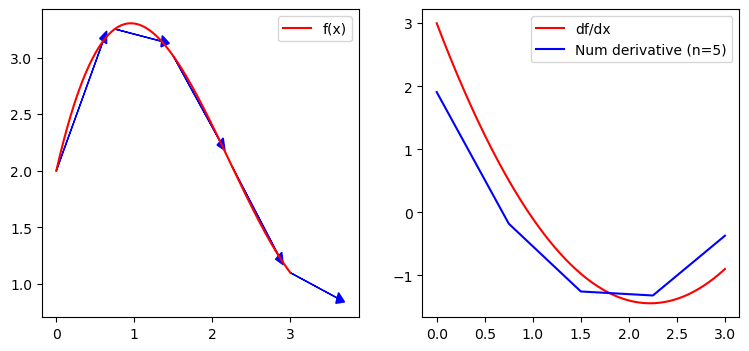

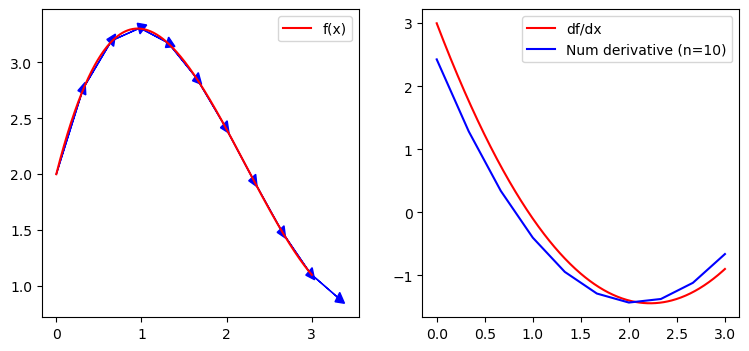

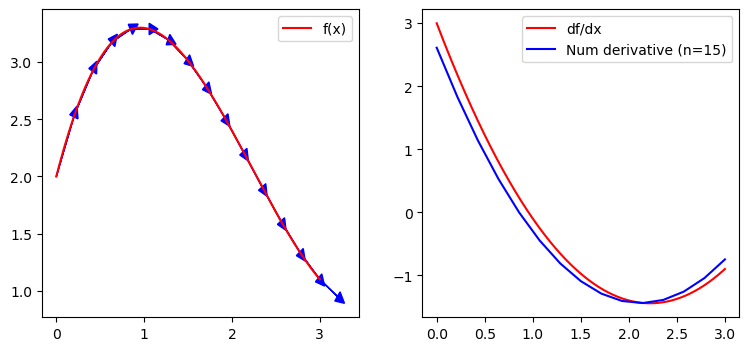

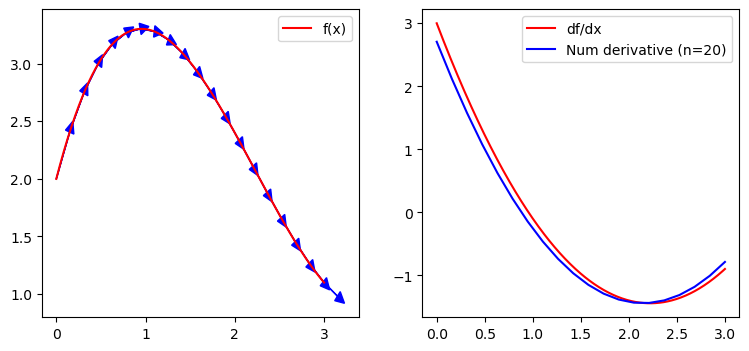

In [4]:
import numpy as np 
import matplotlib.pyplot as plt 

def fx(x):
    return 0.3*x**3 -2*x**2 + 3*x + 2

def dfx(x):
    return 0.9*x**2 -4*x + 3

def ddfx(x):
    return 1.8*x - 4

def derivative_forward(f, a, b, n):
    x = np.linspace(a, b, num = n)
    h = (b-a)/n 
    der = (f(x+h)-f(x))/h
    return [der, x, h]

a = 0.0
b = 3.0

x_plot = np.linspace(a, b, num = 500)

N = np.array([5,10,15,20])

for n in N:

    der, x, h = derivative_forward(fx, a, b, n)

    fig = plt.figure(figsize=(9,4))
    ax1 = fig.add_subplot(121)
    ax1.plot(x_plot,fx(x_plot),'r', label="f(x)") 
    for xi in x:
        ax1.arrow(xi, fx(xi), h, fx(xi+h)-fx(xi), head_width=0.1, head_length=0.1, color='b')
    ax2 = fig.add_subplot(122)
    ax2.plot(x_plot, dfx(x_plot),'r', label="df/dx")
    ax2.plot(x, der, 'b', label=f"Num derivative (n={n})")

    ax1.legend(loc="upper right")
    ax2.legend(loc="upper right")



We can see that as the number of segments increases, the derivative becomes more precise. 

Below, we consider what happens as the number of segments increases even more.

In [5]:
N = np.array([1e2, 1e3, 1e4, 1e5, 1e6], dtype=int)

for n in N:

    der, x, h = derivative_forward(fx, a, b, n)
    der_analytical = dfx(x)

    error = np.abs((der-der_analytical)/der_analytical)

    error_max = np.max(error)
    error_avg = np.mean(error)

    print(f"For n = {n}, the maximum relative error in the derivative is {error_max:.4e}. The average error is {error_avg:.4e}.")

For n = 100, the maximum relative error in the derivative is 1.0320e+00. The average error is 5.5376e-02.
For n = 1000, the maximum relative error in the derivative is 3.6951e+00. The average error is 1.0239e-02.
For n = 10000, the maximum relative error in the derivative is 2.3037e+00. The average error is 1.1196e-03.
For n = 100000, the maximum relative error in the derivative is 1.3822e+01. The average error is 2.4961e-04.
For n = 1000000, the maximum relative error in the derivative is 2.1949e+00. The average error is 1.5700e-05.


To explore the limit of N increasing further (h decreasing) without running out of memory, we consider the code below for a single value of x:

$$
x = 1.0
$$

The error due to the approximation is:

$$
\delta_A \approx \frac{h}{2}\lvert f''(x) \rvert
$$

The error due to machine precision is:

$$
\delta_P \approx \frac{2\epsilon}{h} \lvert f(x) \rvert
$$

The total error is

$$
\delta = \delta_A + \delta_P
$$

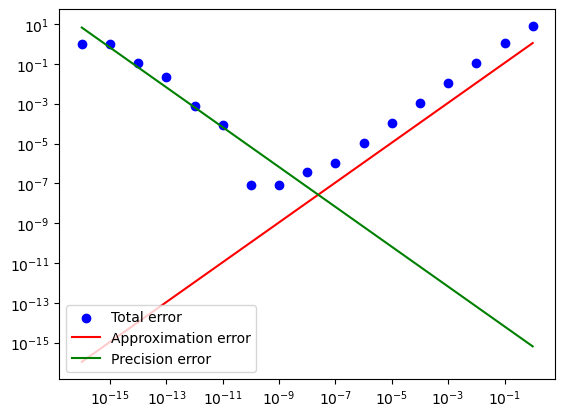

In [15]:
def num_der_slice(f,x,h):
    return (f(x+h)-f(x))/h 

x = 1.0
H = np.array([1, 1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8, 1e-9, 1e-10, 1e-11, 1e-12, 1e-13, 1e-14, 1e-15, 1e-16])

error = np.zeros(H.size)
delta_A = np.zeros(H.size)
delta_P = np.zeros(H.size)
epsilon = 1e-16

for i, h in enumerate(H):
    num_der = num_der_slice(fx, x, h)
    error[i] = np.abs((num_der-dfx(x))/dfx(x))
    delta_A[i] = h/2.0*np.abs(ddfx(x))
    delta_P[i] = 2*epsilon/h*np.abs(fx(x))

fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(H,error, color='b', label="Total error")
ax.plot(H, delta_A, color='r', label="Approximation error")
ax.plot(H, delta_P, color='g', label="Precision error")
ax.legend(loc='lower left')
ax.set_xscale('log')
ax.set_yscale('log')

## 1st order derivative: central difference method

We can calculate a more accurate 1st derivative. The equation can be derived with the Taylor series:

$$
\frac{df}{dx} \approx \frac{f(x+h/2)-f(x-h/2)}{h}
$$

In [16]:
def derivative_central(f, a, b, n):
    x = np.linspace(a, b, num = n)
    h = (b-a)/n 
    der = (f(x+h/2)-f(x-h/2))/h
    return [der, x, h]

N = np.array([1e2, 1e3, 1e4, 1e5, 1e6], dtype=int)

for n in N:

    der, x, h = derivative_central(fx, a, b, n)
    der_analytical = dfx(x)

    error = np.abs((der-der_analytical)/der_analytical)

    error_max = np.max(error)
    error_avg = np.mean(error)

    print(f"For n = {n}, the maximum relative error in the derivative is {error_max:.4e}. The average error is {error_avg:.4e}.")


For n = 100, the maximum relative error in the derivative is 2.0765e-03. The average error is 1.2677e-04.
For n = 1000, the maximum relative error in the derivative is 7.2953e-04. The average error is 2.1899e-06.
For n = 10000, the maximum relative error in the derivative is 4.5445e-05. The average error is 2.3773e-08.
For n = 100000, the maximum relative error in the derivative is 1.7466e-05. The average error is 4.1455e-10.
For n = 1000000, the maximum relative error in the derivative is 2.2195e-05. The average error is 4.8818e-10.


The results are more accurate than we had previously with the forward method.

## 1st order derivative: higher order approximation

Using Taylor, we can derive more and more accurate equations for the first derivative. Central methods include:

$$
\frac{df}{dx} \approx \frac{\frac{1}{24}f(x-3h/2)-\frac{27}{24}f(x-h/2)+\frac{27}{24}f(x+h/2)-\frac{1}{24}f(x+3h/2)}{h}
$$

$$
\frac{df}{dx} \approx \frac{-\frac{3}{640}f(x-5h/2) + \frac{25}{384}f(x-3h/2)-\frac{75}{64}f(x-h/2)+\frac{75}{64}f(x+h/2)-\frac{25}{384}f(x+3h/2)+\frac{3}{640}f(x+5h/2)}{h}
$$

Etc. Each of these have decreasing approximation errors. We can also derive similarly accurate formulae for forward (or backward) methods. For example:

$$
\frac{df}{dx} \approx \frac{-3f(x) + 4f(x+h)-f(x+2h)}{2h}
$$

These forward and backward methods are especially useful when we don't have access to the analytical function (such as with data) and have to deal with the boundaries of x.
